## Q1

2991834.6734
final mean: 2991834.6733999965
5000 5000
-1540.625


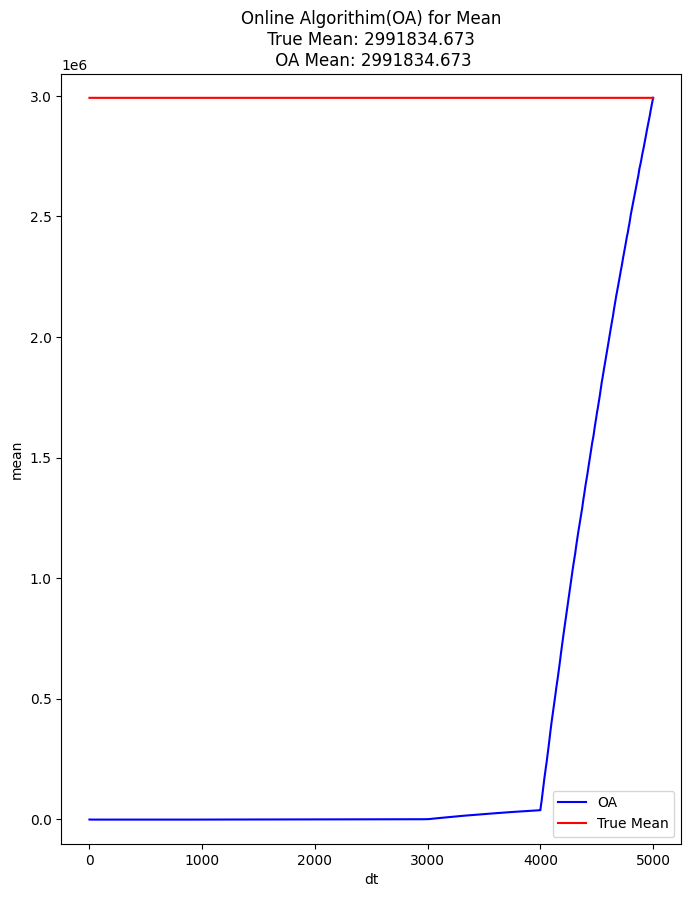

In [22]:
# load libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# quick check data-1.txt has 5000 pts
# cat data-1.txt | wc -l -> 5000

# load data-1.txt
data = np.loadtxt('data-1.txt')

def online_algorithm_mean(data):
    mean_i = []
    dt = []
    current_mean = 0
    for t,x_t in enumerate(data):
        dt.append(t+1)
        current_mean = current_mean + ((x_t-current_mean)/(t+1))
        mean_i.append(current_mean)
    print(f"final mean: {mean_i[-1]}")
    return dt, mean_i

def plot_mean_dt(dt,mean_i,true_mean):
    fig,ax = plt.subplots(nrows=1,ncols=1,figsize=(8,10))
    sns.lineplot(x=dt,y=mean_i,markers='o',ax=ax,color='blue',label='OA')
    sns.lineplot(x=dt,y=[true_mean for i in dt],markers='--',ax=ax,color='red',label='True Mean')
    ax.set_xlabel('dt')
    ax.set_ylabel('mean')
    ax.set_ylim(min(mean_i)-1e5,true_mean+1e5)
    print(min(mean_i))
    title = f"Online Algorithim(OA) for Mean\n True Mean: {true_mean:.3f} \n OA Mean: {mean_i[-1]:.3f}"
    ax.set_title(title)
    fig.savefig('hw3_q1.png')

# calc true mean
true_mean = sum(data)/len(data)
print(true_mean)

dt, mean_i = online_algorithm_mean(data)
print(len(dt),len(mean_i))
plot_mean_dt(dt,mean_i,true_mean)



## Q2

In [ ]:
# load libraries
import numpy as np

# load data-1.txt
data = np.loadtxt('data-1.txt')

def online_variance(data):
    """
    Computes the variance of a dataset in an online fashion.
    
    Returns:
        A list of the variance at each step t.
    """
    t = 0
    mean_x = 0.0
    mean_x_squared = 0.0
    variances = []

    for x_t in data:
        # Increment count
        t += 1
        
        # Update the mean of x
        mean_x += (x_t - mean_x) / t
        
        # Update the mean of x-squared
        mean_x_squared += (x_t**2 - mean_x_squared) / t
        
        # Calculate and store the current variance
        # For the first point, variance is 0. For others, calculate it.
        if t < 2:
            current_var = 0.0
        else:
            # We use a slightly more numerically stable formula here for the final calculation
            # which is equivalent to mean_x_squared - mean_x**2
            # For a dataset of size t, the sample variance uses t-1 in the denominator.
            # The population variance uses t. np.var uses population by default.
            current_var = mean_x_squared - mean_x**2
        
        variances.append(current_var)
        
    return variances